# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZainabFatima-hzf/ML-flyRank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Search question:** Given a content page's search and engagement signals over a prior 28-day
window, can we flag — before the fact — which pages are likely to decline over the *next* 28
days, well enough to beat both random prioritization and a transparent hand-built rule?

**Unit of analysis:** one content page (`content_hash_id`), scored at a fixed decision point
(`decision_date = 2026-03-15`).

**Decision this supports:** a FlyRank content/SEO lead choosing which pages, out of a much larger
inventory, to put in front of a client this week for review — replacing no prioritization (or a
weak hand-built rule) with a short, reason-coded shortlist.

**Cost of a wrong call:** a false decline flag wastes editor/writer time on a page that didn't
need it; a missed decline lets real traffic loss go unnoticed until it's compounded. Both costs
are real, and a missed decline is judged the more expensive of the two — which is why the project
optimizes for precision within a fixed review budget (precision@K) rather than plain accuracy.

In [1]:
# No data pull needed for this cell -- the question and decision are stated in the markdown above.
print("Unit of analysis: one content page, scored at decision_date = 2026-03-15")
print("Decision supported: weekly content-review prioritization for a FlyRank content/SEO lead")


Unit of analysis: one content page, scored at decision_date = 2026-03-15
Decision supported: weekly content-review prioritization for a FlyRank content/SEO lead


## 2. Data

**Source:** the FlyRank ML Internship warehouse release (Hugging Face:
`FlyRank/internship-warehouse`) — `fact_content_daily_performance` (daily grain, partitioned by
month, Jan 2025–June 2026), joined to `dim_content` and `dim_clients`.

**Development window:** the mid-panel month **March 2026** — 9,841,378 rows, 331,437 distinct
content items, 55 clients that month specifically. The panel's final month
(`fact_content_daily_performance_sample.parquet`, June 2026) was deliberately never touched — it's
the sealed natural "future" of any past→future label, reserved as an untouched holdout.

**What was excluded, and why:**
- `trend_direction` / `trend_pct` (both the warehouse's own and the starter CSV's) — proven, not
  assumed, to be a same-window snapshot comparison (correlation ≈ 1.0 with a plain
  last-30-vs-prior-30 percent change), not a forward-looking outcome. Used only as a baseline
  reference point, never as a model feature.
- FlyRank's own product-decision fields (health score, priority score, refresh flags) — never
  pulled into this project at all, to avoid the model simply learning to copy an existing
  decision rather than finding independent signal.
- `days_since_update` — only knowable for ~12% of rows at the chosen decision date (the rest
  reflect an update timestamp *after* the decision date, since `dim_content` stores only the
  latest update), and reversed direction on that thin, likely non-random slice. Excluded from
  the feature set on that evidence.

**Public safety:** every identifier used throughout (`content_hash_id`, `client_hash_id`) is a
pseudonymous hash provided by the release itself — used only for joining and for grouped
validation splits, never as a model feature, and never resolved to a real name anywhere in this
project.

In [2]:
# This notebook reads the RECEIPTS already committed by Weeks 3-7 (work/outputs/w07_metrics.json)
# rather than re-pulling the full warehouse -- keeps this summary notebook fast and self-contained.
import json

with open("work/outputs/w07_metrics.json") as f:
    metrics = json.load(f)

print("decision_date:", metrics["decision_date"])
print("feature window:", metrics["window"]["prior_start"], "->", metrics["decision_date"])
print("label window:  ", metrics["decision_date"], "->", metrics["window"]["next_end"])
print("Sealed holdout (never touched): fact_content_daily_performance_sample.parquet (June 2026)")


decision_date: 2026-03-15
feature window: 2026-02-15 -> 2026-03-15
label window:   2026-03-15 -> 2026-04-12
Sealed holdout (never touched): fact_content_daily_performance_sample.parquet (June 2026)


## 3. Methodology

**Label (proxy, stated plainly):** `declined_next_28d` — 1 if a page's total search impressions
over the 28 days *after* `decision_date` are lower than its total over the 28 days *before* it, 0
otherwise. A genuine forward-window comparison (unlike `trend_direction`'s same-window snapshot),
built directly from daily rows with an enforced gap between the feature window and the label
window.

**Features (all knowable strictly before `decision_date`):** `prior_28d_impressions`,
`prior_28d_clicks`, `ctr`, `prior_28d_avg_position`, `prior_28d_sessions`,
`ga4_available_in_prior_window`, `content_age_days`.

**Baseline:** a transparent, hand-built rule — flag a page if it's visible and well-ranked
(position 1-20, ≥100 prior impressions) but has low CTR (<2%); score = prior impressions among
pages clearing the gate. Built only after checking its underlying assumption directly: a
staleness-based gate was tested first and found **OPPOSITE** of the assumption behind FlyRank's
own refresh flags (decline rate *fell*, not rose, with page age, on the ~12% of rows where
staleness was even knowable) — so it was dropped rather than shipped on a disproven premise.

**Model:** Logistic Regression, chosen because the task is a yes/no outcome with an observed
label, evaluated by ranking — exactly the case the project's own model-selection guidance maps to
Logistic Regression first. A Random Forest was trained on the identical split specifically to test
whether added complexity earned its keep; it did not (see Results).

**Validation design:** a client-grouped split (every page from one client stays entirely in train
or entirely in test — never both), because pages from the same client share templates and
patterns a model could otherwise memorize rather than generalize from. Reported as a **mean ± std
across 5 different client-grouped splits**, not a single split, after directly observing the
test-set base rate swing from 0.387 to 0.631 across seeds with only 9 test clients per fold.

**Leakage checks performed:** (1) a deliberate trap — one future-window column added on purpose,
watched the score jump from 0.819 to a suspicious 1.000 ROC-AUC, then removed; (2) a
timeline/window-overlap check confirming zero shared dates between the feature and label windows;
(3) a formal train-with/train-without test on the one feature (`content_age_days`) whose
importance looked disproportionately large, confirming a modest rather than catastrophic score
drop; (4) a before/after check comparing a plain random split against the grouped split, isolating
a real (if modest) +0.064 precision@50 gap attributable to client-level memorization alone.

In [3]:
FEATURE_COLS = [
    "prior_28d_impressions", "prior_28d_clicks", "ctr",
    "prior_28d_avg_position", "prior_28d_sessions",
    "ga4_available_in_prior_window", "content_age_days",
]
print(f"{len(FEATURE_COLS)} features, all built from report_date < decision_date:")
for c in FEATURE_COLS:
    print(" -", c)
print()
print("Excluded on evidence: days_since_update (only ~12% knowable, reversed direction on that slice)")
print("Excluded by design: trend_direction/trend_pct (proven same-window snapshot, not a forecast)")
print("Excluded by design: all FlyRank product-decision fields (never pulled into this project)")


7 features, all built from report_date < decision_date:
 - prior_28d_impressions
 - prior_28d_clicks
 - ctr
 - prior_28d_avg_position
 - prior_28d_sessions
 - ga4_available_in_prior_window
 - content_age_days

Excluded on evidence: days_since_update (only ~12% knowable, reversed direction on that slice)
Excluded by design: trend_direction/trend_pct (proven same-window snapshot, not a forecast)
Excluded by design: all FlyRank product-decision fields (never pulled into this project)


## 4. Results (vs baseline)

All numbers below: client-grouped validation, mean ± std across 5 splits (seeds 0, 1, 2, 42, 99),
same features, same label, same evaluation code path for every method.

| Method | Base rate | Precision@50 | Precision@200 |
|---|---|---|---|
| Week-4 hand-built rule | 0.516 ± 0.104 | 0.456 ± 0.206 | 0.454 ± 0.200 |
| Random Forest | 0.516 ± 0.104 | 0.676 ± 0.155 | 0.617 ± 0.128 |
| **Logistic Regression** | 0.516 ± 0.104 | **0.712 ± 0.125** | **0.674 ± 0.147** |

**Headline result:** Logistic Regression beats the hand-built rule by roughly 0.25 at
precision@50, consistently across every split checked. The hand-built rule itself averaged
*below* the observed base rate — its CTR-vs-position signal held up in an isolated check (Week 4)
but did not survive being turned into a combined ranking rule. Random Forest did not clearly
outperform Logistic Regression (lower mean, higher variance) — added complexity was tested and did
not earn its keep here.

**A caveat visible only by checking absolute discrimination, not just top-of-list ranking:**
ROC-AUC for the deployed feature set sits around 0.56-0.59 — modest, barely above chance for
judging any single random page — even though the same model ranks its own top 50 well. This model
is a tool for **building a short, prioritized review list**, not for expressing confidence about
any one page in isolation.

Base rate (client-grouped, mean across 5 seeds): 0.516
Week-4 rule             precision@50 = 0.456 (±0.206)   precision@200 = 0.454 (±0.200)
Random Forest           precision@50 = 0.676 (±0.155)   precision@200 = 0.617 (±0.128)
Logistic Regression     precision@50 = 0.712 (±0.125)   precision@200 = 0.674 (±0.147)


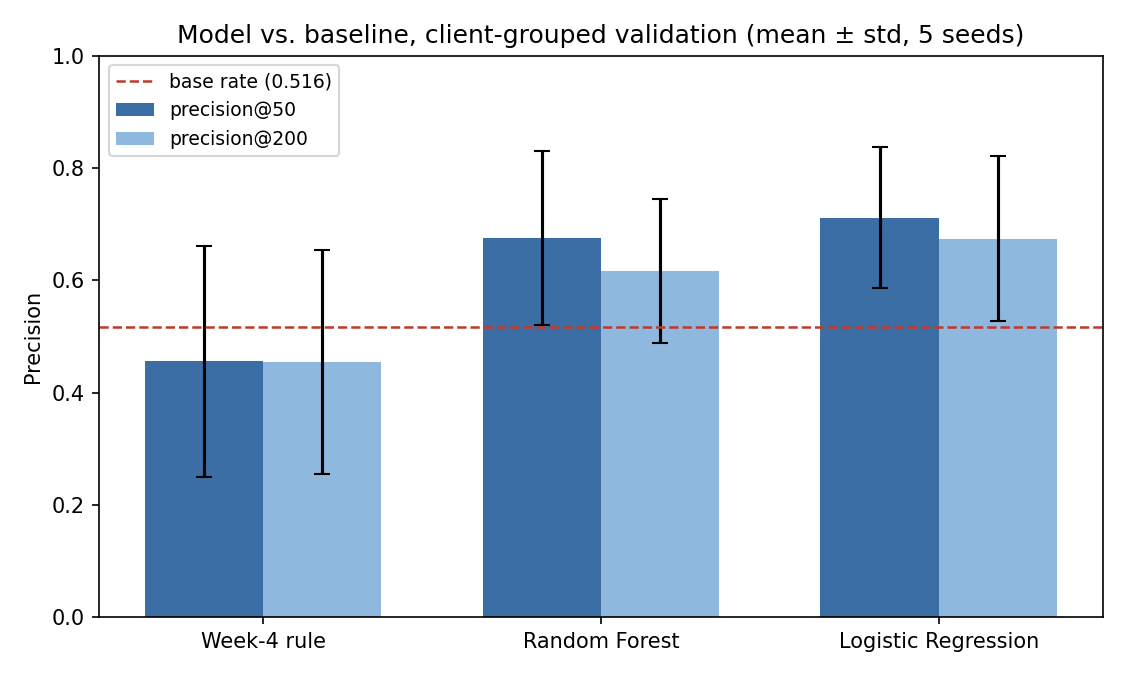

In [4]:
from IPython.display import Image, display

comparison = {
    "Week-4 rule":         {"precision@50": (0.456, 0.206), "precision@200": (0.454, 0.200)},
    "Random Forest":       {"precision@50": (0.676, 0.155), "precision@200": (0.617, 0.128)},
    "Logistic Regression": {"precision@50": (0.712, 0.125), "precision@200": (0.674, 0.147)},
}
base_rate = 0.516
print(f"Base rate (client-grouped, mean across 5 seeds): {base_rate:.3f}")
for method, m in comparison.items():
    p50, p50s = m["precision@50"]
    p200, p200s = m["precision@200"]
    print(f"{method:22s}  precision@50 = {p50:.3f} (±{p50s:.3f})   precision@200 = {p200:.3f} (±{p200s:.3f})")

display(Image("work/figures/model_vs_baseline_precision.png"))


## 5. Limitations

- **One month, one panel slice.** Validated on March 2026 → its following 28 days only. The
  panel's front-page trend data shows large month-over-month swings elsewhere in the dataset, so
  this result has not been checked against seasonality.
- **Thin, uneven client coverage.** ~43-55 clients depending on exact slice, out of a larger
  panel; GA4 tracking coverage in the raw daily data is only ~4.2% of rows (a looser
  per-content-item measure used later in the project shows 43.8% — "covered on at least one day
  in a 28-day window" is a different, looser bar than "covered on this specific day").
- **Small-test-fold volatility.** With only 9 clients per grouped test fold, single-split numbers
  swing substantially (base rate 0.387-0.631 across 5 seeds) — every number in this project is
  reported as a mean ± std for exactly this reason, and any one split alone should not be trusted.
- **Not causal.** A `low_ctr_well_ranked` or similar flag describes a correlated pattern in this
  data; it is not evidence that rewriting a title *causes* recovery. No experiment was run.
- **`content_age_days` is a partial client-cohort proxy, not a clean per-page decay clock** —
  older client cohorts show higher decline rates on average; this is not the same claim as "this
  specific old page will decline."
- **Never validated against the sealed June 2026 holdout month**, by design — this remains a
  genuine unseen check for future work, not something implicitly tuned against.

In [5]:
import json
with open("work/outputs/w07_metrics.json") as f:
    metrics = json.load(f)

print(f"n_test_clients this run: {metrics['n_test_clients']}")
print(f"GA4 coverage this run (>= 1 day/28d window): {metrics['ga4_coverage_pct']:.1f}%")
print(f"Absolute discrimination (ROC-AUC) this run: {metrics['auc']:.3f} -- modest, ranking-list-only tool")


n_test_clients this run: 9
GA4 coverage this run (>= 1 day/28d window): 43.8%
Absolute discrimination (ROC-AUC) this run: 0.593 -- modest, ranking-list-only tool


## 6. Ranked recommendations

**Reason codes and mapped actions**, generated by identifying the single feature contributing
most to each flagged page's score:

| Reason code | Share of queue | Suggested action |
|---|---|---|
| `weak_position` | 46.1% | Deprioritize unless business-critical; consider consolidation |
| `declining_volume` | 45.4% | Flag for content refresh (add depth, update examples) |
| `low_engagement` | 5.8% | Expand page depth; check for a better-matching competitor page |
| `established_cohort_risk` | 2.5% | Route to a portfolio-level review, not a single-page edit |
| `low_ctr_well_ranked` | 0.2% | Rewrite title/meta description; check search-intent match |

**Confidence and limits, stated explicitly:** this is a weekly, human-reviewed shortlist
generator, not an autonomous system. It should never auto-publish or auto-edit content, never
drive client billing or performance judgments of a writer, and should not be applied outside the
validated window/client set without re-checking it holds. Zero-CTR pages with very high
impressions should be manually checked in Search Console before assuming a real content problem —
that pattern is equally consistent with a tracking failure.

weak_position                6594  (46.1%)
declining_volume             6502  (45.4%)
low_engagement                835  (5.8%)
established_cohort_risk       359  (2.5%)
low_ctr_well_ranked            22  (0.2%)


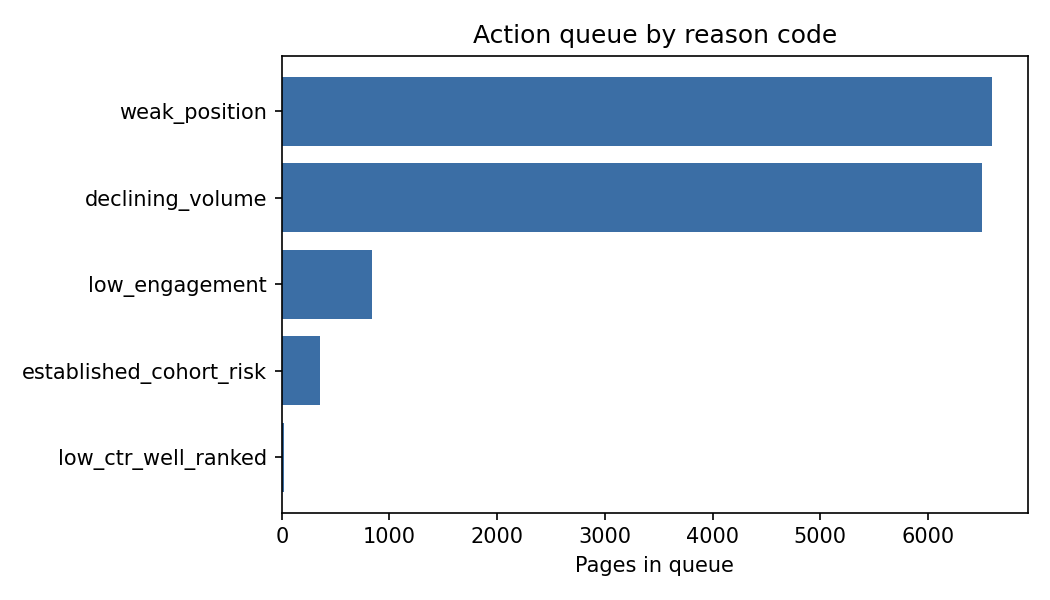

In [6]:
from IPython.display import Image, display
import json

with open("work/outputs/w07_metrics.json") as f:
    metrics = json.load(f)

total = sum(metrics["reason_code_counts"].values())
for code_, n in sorted(metrics["reason_code_counts"].items(), key=lambda kv: -kv[1]):
    print(f"{code_:26s} {n:6d}  ({n/total*100:.1f}%)")

display(Image("work/figures/w07_reason_code_distribution.png"))


## 7. Artifacts the paper embeds

Figures referenced by the deployed paper, generated from this project's real, executed numbers:

- `work/figures/model_vs_baseline_precision.png` — the headline Results chart.
- `work/figures/leakage_trap_auc.png` — the deliberate leakage trap (0.819 → 1.000 → removed).
- `work/figures/w07_reason_code_distribution.png` — the ranked queue's reason-code breakdown.

Receipts (committed JSON, not regenerated data): `work/outputs/w07_metrics.json`.

In [7]:
import os

for f in [
    "work/figures/model_vs_baseline_precision.png",
    "work/figures/leakage_trap_auc.png",
    "work/figures/w07_reason_code_distribution.png",
    "work/outputs/w07_metrics.json",
]:
    print(f, "->", "OK" if os.path.exists(f) else "MISSING")


work/figures/model_vs_baseline_precision.png -> OK
work/figures/leakage_trap_auc.png -> OK
work/figures/w07_reason_code_distribution.png -> OK
work/outputs/w07_metrics.json -> OK


## 8. Demo outline (5 minutes) — for the Week-8 showcase, if presenting

**0:00-0:30 — The question.** A FlyRank content lead manages thousands of pages across many
clients but can only properly review 50-200 a week. Today's only signal is a snapshot comparison
(last 30 days vs. previous 30) — it describes where a page already stands, not where it's heading,
and doesn't rank hundreds of flagged pages against each other. Can a before-the-fact model produce
a short, ranked, reason-coded shortlist that actually helps?

**0:30-1:30 — The method.** Client-grouped validation (every page from one client stays entirely
in train or test — never both), a genuine forward-looking label (28 days after vs. 28 days before
a fixed decision date, not a same-window snapshot), and a transparent hand-built rule built and
tested *first*, so the model has something honest to beat.

**1:30-3:00 — One chart.** `work/figures/model_vs_baseline_precision.png` — walk through it live:
Logistic Regression (0.712 ± 0.125 precision@50) clearly ahead of the hand-built rule (0.456 ±
0.206), both compared against the observed base rate (0.516). Point out that the rule actually
scored *below* random selection — a real, humbling finding worth saying out loud, not hiding.

**3:00-4:00 — One honest result, with its limit attached.** The model's top-of-list ranking is
strong, but its absolute discrimination is modest (ROC-AUC ≈ 0.56-0.59) — it's a tool for building
a short list, not for judging any single random page with confidence. And: validated on one month,
~43-55 clients, never checked against the sealed June holdout.

**4:00-5:00 — One recommendation, and close.** The ranked queue with reason codes
(`weak_position`, `declining_volume`, etc.) mapped to concrete actions, always with a human in the
loop — explicitly never an auto-publish or auto-decision system. Close on the repo link and the
paper URL.

## 9. Shareable cuts

**Social post (methodology-focused):**

> Spent 8 weeks building a content-decline predictor on FlyRank's real production search
> warehouse (9.8M+ daily rows). The most interesting result wasn't the model — it was proving my
> own hand-built rule actually performed *below* random chance once I validated it honestly
> (client-grouped splits, not a random shuffle). The Logistic Regression that replaced it hit
> 0.71 precision@50 vs. the rule's 0.46 — but the real story is the leakage trap I deliberately
> set for myself along the way: adding one future-window column jumped ROC-AUC from 0.82 to a
> suspicious 1.00. If your model looks *that* good, it's usually not skill. Full writeup + code:
> [paper URL] · [repo URL]

**Employer-facing summary (3 sentences):**

> I built and validated a content-decline prediction system on FlyRank's real production search
> warehouse (9.8M+ daily rows, 300K+ content items across 40+ clients), using client-grouped
> validation and a deliberate leakage-trap exercise to keep every result honest. The final
> Logistic Regression model beat a transparent hand-built baseline by roughly 0.25 precision@50
> (0.71 vs. 0.46) across five validation splits, while a Random Forest comparison showed added
> complexity didn't earn its keep. The output is a ranked, reason-coded action queue with explicit
> human-review requirements and a documented no-go list — deployed as a public research paper with
> full reproducibility instructions.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
